In [1]:
from math import pi
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
TIME_STR = "20250728-163629"
FOLDER_PATH = f"data/{TIME_STR}"
SERVO_COMMAND_FILE_PATH = f"{FOLDER_PATH}/servo_command.csv"
SERVO_STATE_FILE_PATH = f"{FOLDER_PATH}/servo_state.csv"

POSITION_COMMAND_FILE_PATH = f"{FOLDER_PATH}/position_command.csv"
POSITION_STATE_FILE_PATH = f"{FOLDER_PATH}/position_state.csv"

NUM_JOINTS = 6
NUM_SERVOS = 7
COLORS = ["red", "orange", "brown", "green", "blue", "purple", "magenta"]
OPACITY_CMD = 1
OPACITY_STATE = 1
MARKER_SIZE = 1

In [3]:
servo_cmd = pd.read_csv(SERVO_COMMAND_FILE_PATH)
# servo_cmd

In [4]:
servo_state = pd.read_csv(SERVO_STATE_FILE_PATH)
# servo_state

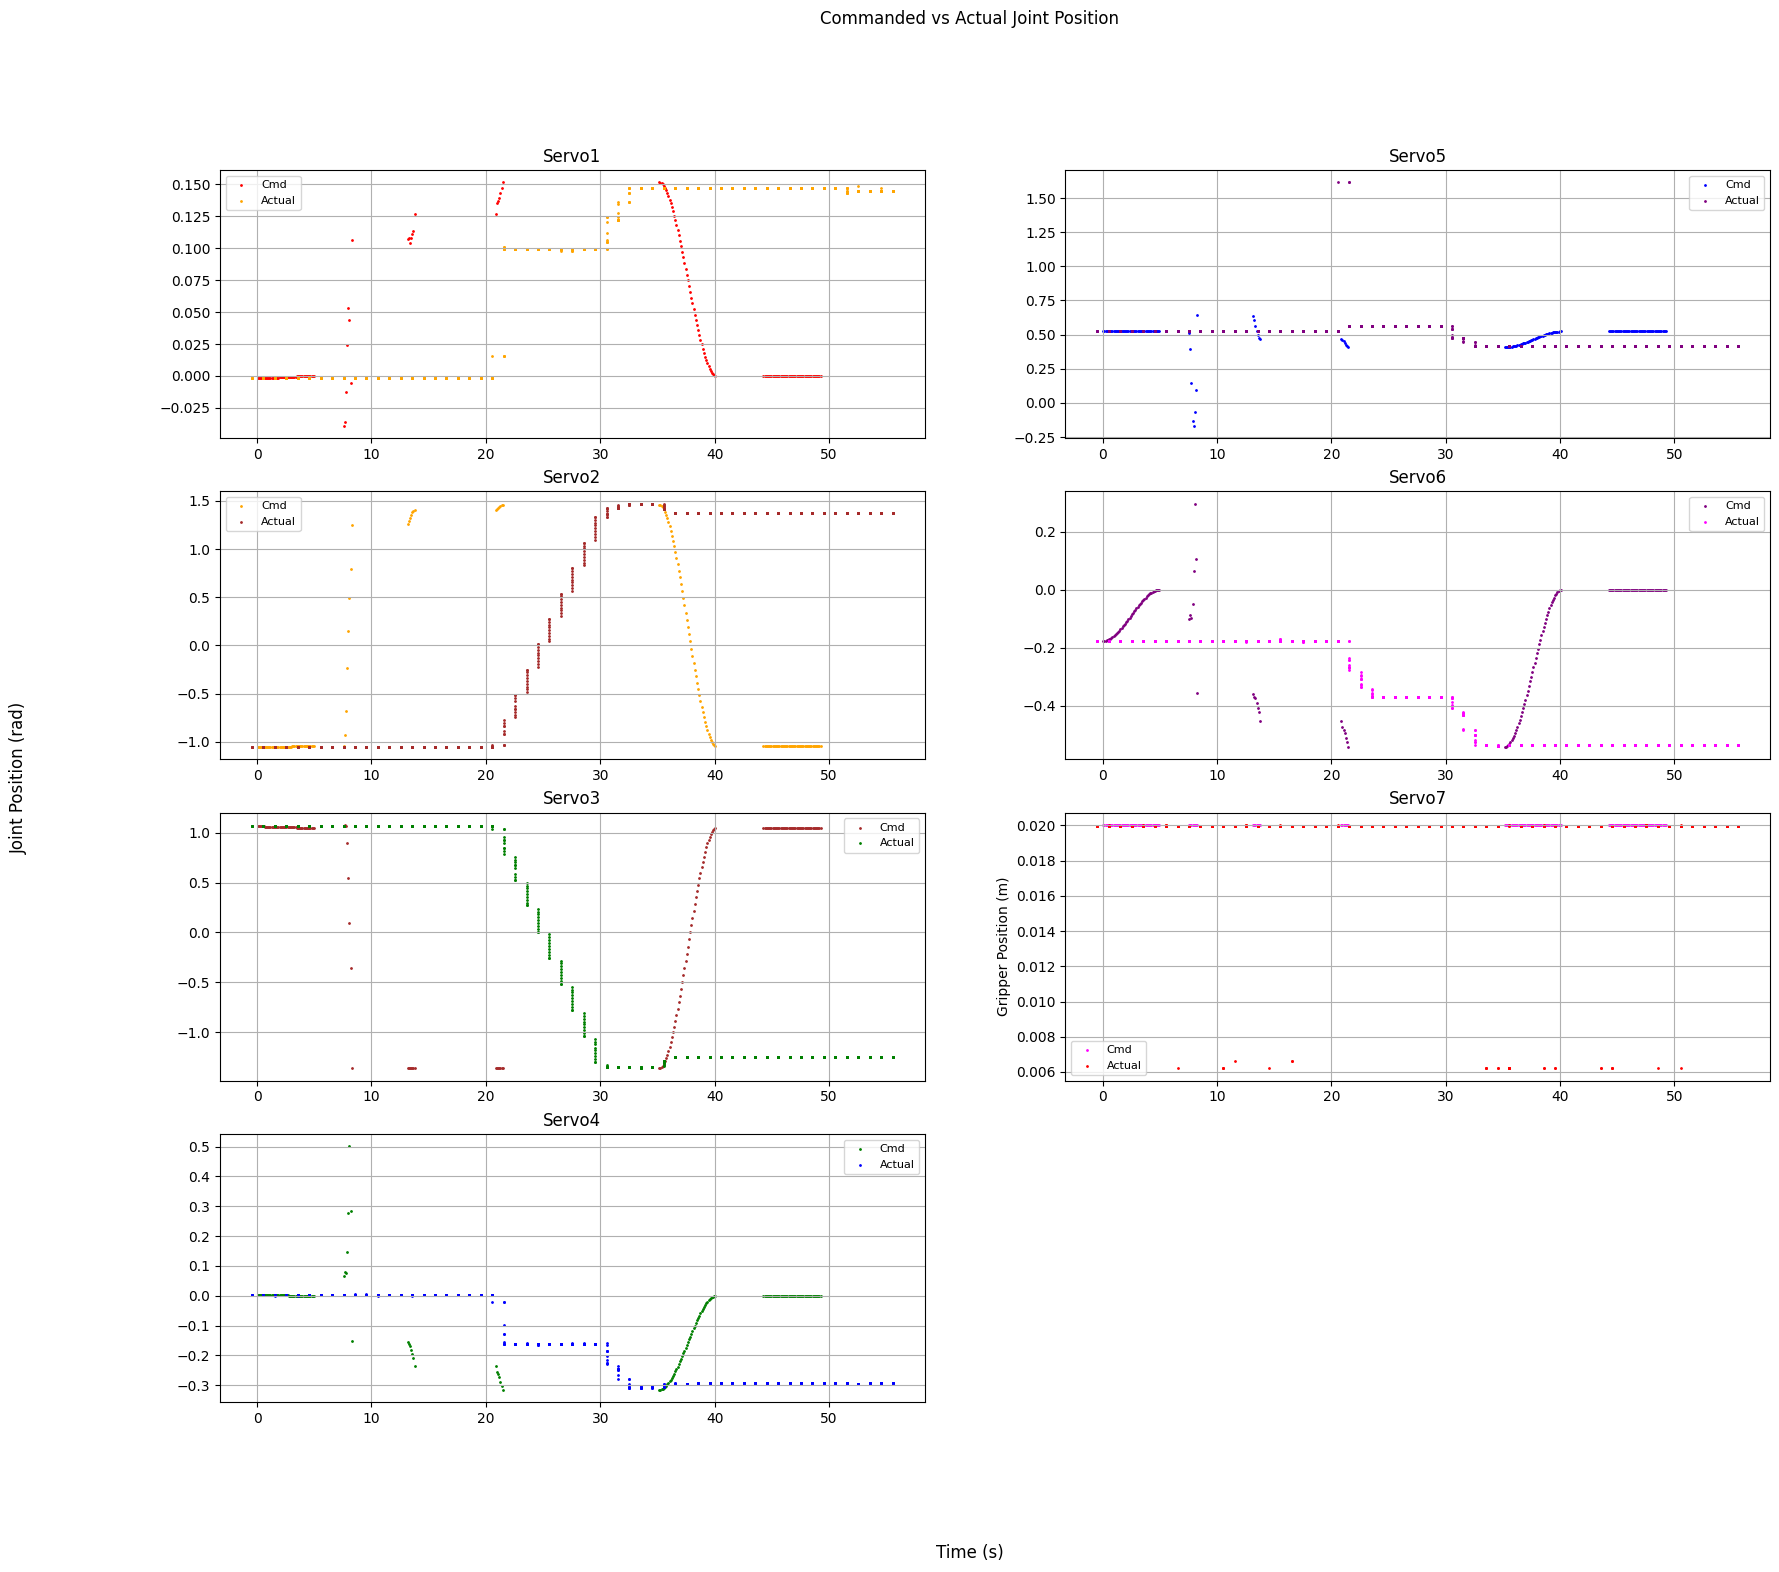

In [5]:
# fig, axes = plt.subplots(2, 4, constrained_layout=True)
fig, axes = plt.subplots(4, 2, figsize=(20, 16))
                         
for i in range(NUM_SERVOS + 1):
    col = i // 4
    row = i % 4

    if i == NUM_SERVOS:
        axes[row, col].set_visible(False)
        break

    # Plot servo{i} from command data
    axes[row, col].scatter(
        servo_cmd['time'], 
        servo_cmd[f'servo{i + 1}'], 
        label='Cmd', 
        color=COLORS[i],
        alpha=OPACITY_CMD,
        s=MARKER_SIZE
    )

    # Plot servo{i} from state data
    axes[row, col].scatter(
        servo_state['time'], 
        servo_state[f'servo{i + 1}'], 
        label='Actual', 
        color=COLORS[i + 1] if i < NUM_JOINTS else COLORS[0], 
        alpha=OPACITY_STATE,
        s=MARKER_SIZE
    )

    axes[row, col].set_title(f"Servo{i + 1}")
    axes[row, col].legend(fontsize=8, loc='best')

    if i + 1 == NUM_SERVOS:
        axes[row, col].set_ylabel("Gripper Position (m)")

    axes[row, col].grid()

# Add labels and title
fig.supxlabel('Time (s)')
fig.supylabel('Joint Position (rad)')
fig.suptitle('Commanded vs Actual Joint Position')

plt.show()

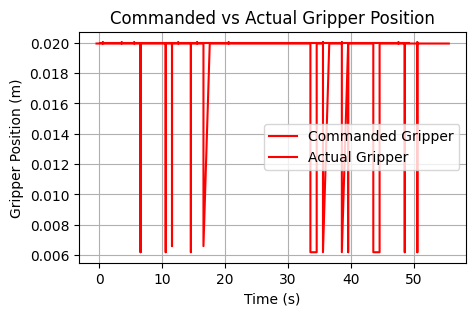

In [6]:
# Create a figure and axis
plt.figure(figsize=(5, 3))


# Plot servo{i} from command data
plt.plot(
    servo_cmd['time'], 
    servo_cmd[f'servo{NUM_SERVOS}'], 
    label='Commanded Gripper', 
    color=COLORS[0]
)

# Plot servo{i} from state data
plt.plot(
    servo_state['time'], 
    servo_state[f'servo{NUM_SERVOS}'], 
    label='Actual Gripper', 
    color=COLORS[0], 
    alpha=OPACITY_STATE
)

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Gripper Position (m)')
plt.title('Commanded vs Actual Gripper Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

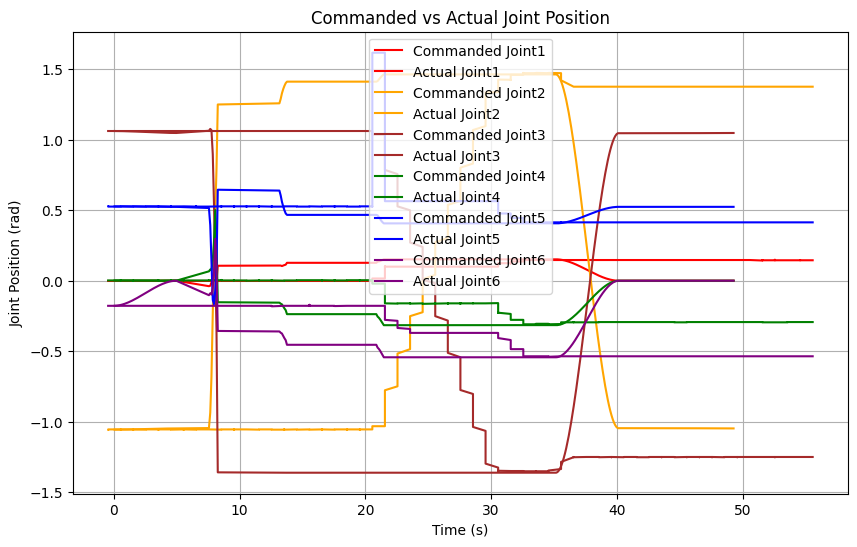

In [7]:
# Create a figure and axis
plt.figure(figsize=(10, 6))

for i in range(NUM_JOINTS):
    # Plot servo{i} from command data
    plt.plot(
        servo_cmd['time'], 
        servo_cmd[f'servo{i + 1}'], 
        label=f'Commanded Joint{i + 1}', 
        color=COLORS[i]
    )

    # Plot servo{i} from state data
    plt.plot(
        servo_state['time'], 
        servo_state[f'servo{i + 1}'], 
        label=f'Actual Joint{i + 1}', 
        color=COLORS[i], 
        alpha=OPACITY_STATE
    )

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel('Joint Position (rad)')
plt.title('Commanded vs Actual Joint Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

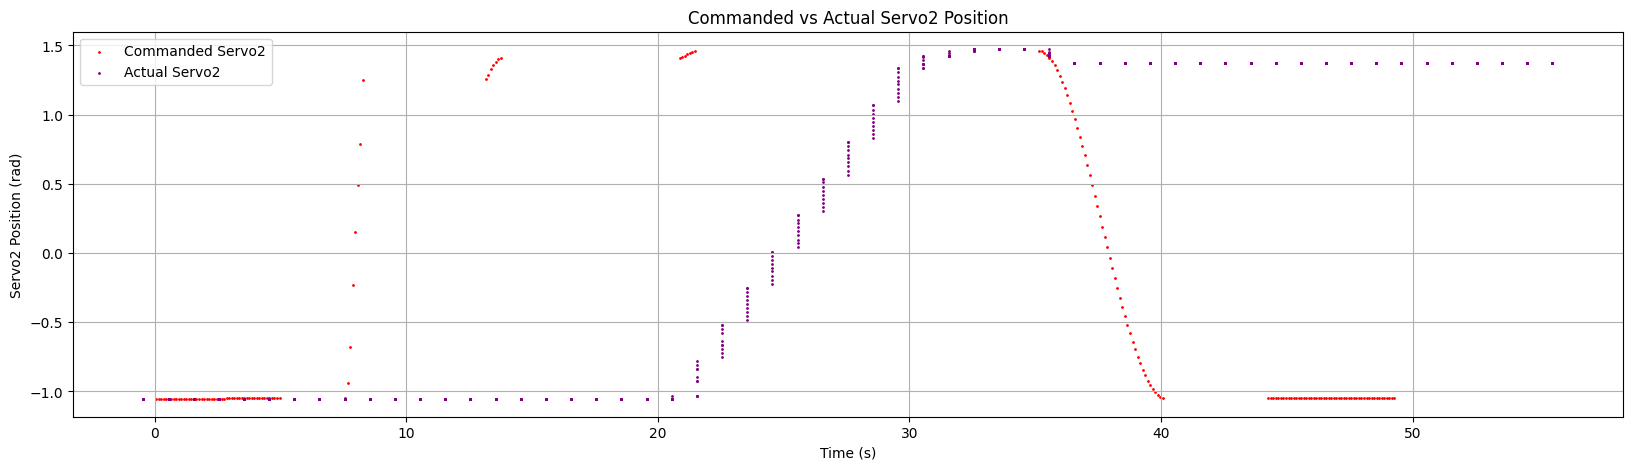

In [8]:
# Create a figure and axis
plt.figure(figsize=(20, 5))

servo_num = 2
# Plot servo{i} from command data
plt.scatter(
    servo_cmd['time'], 
    servo_cmd[f'servo{servo_num}'], 
    label=f'Commanded Servo{servo_num}', 
    color=COLORS[0],
    s=MARKER_SIZE
)

# Plot servo{i} from state data
plt.scatter(
    servo_state['time'], 
    servo_state[f'servo{servo_num}'], 
    label=f'Actual Servo{servo_num}', 
    color=COLORS[5], 
    alpha=OPACITY_STATE,
    s=MARKER_SIZE
)

# Add labels and title
plt.xlabel('Time (s)')
plt.ylabel(f'Servo{servo_num} Position (rad)')
plt.title(f'Commanded vs Actual Servo{servo_num} Position')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

In [9]:
servo_cmd

,time,servo1,servo2,servo3,servo4,servo5,servo6,servo7
0,0.066830,-1.744413e-03,-1.055920,1.061153,1.744413e-03,0.527088,-1.779301e-01,0.02
1,0.166683,-1.739659e-03,-1.055896,1.061115,1.739659e-03,0.527078,-1.774452e-01,0.02
2,0.266621,-1.730996e-03,-1.055853,1.061046,1.730996e-03,0.527061,-1.765616e-01,0.02
3,0.366974,-1.718570e-03,-1.055790,1.060946,1.718570e-03,0.527036,-1.752941e-01,0.02
4,0.466975,-1.702584e-03,-1.055710,1.060818,1.702584e-03,0.527004,-1.736636e-01,0.02
...,...,...,...,...,...,...,...,...
168,48.866773,1.965325e-06,-1.047165,1.047166,-4.090251e-06,0.523597,-7.041136e-06,0.02
169,48.966640,1.122451e-06,-1.047179,1.047180,-2.336054e-06,0.523598,-4.021384e-06,0.02
170,49.066737,5.067789e-07,-1.047189,1.047189,-1.054712e-06,0.523598,-1.815628e-06,0.02
171,49.166759,1.291383e-07,-1.047195,1.047195,-2.687637e-07,0.523599,-4.626614e-07,0.02


In [10]:
servo_state

,time,servo1,servo2,servo3,servo4,servo5,servo6,servo7
0,-0.444226,-0.001745,-1.055924,1.061160,0.001745,0.527089,-0.178024,0.019943
1,-0.444226,-0.001745,-1.054179,1.061160,0.001745,0.525344,-0.178024,0.019943
2,-0.444226,-0.001745,-1.055924,1.061160,0.001745,0.527089,-0.178024,0.019943
3,-0.444226,-0.001745,-1.055924,1.061160,0.001745,0.527089,-0.178024,0.019943
4,-0.444226,-0.001745,-1.054179,1.061160,0.001745,0.525344,-0.178024,0.019943
...,...,...,...,...,...,...,...,...
558,55.555774,0.144862,1.375320,-1.249656,-0.293215,0.413643,-0.535816,0.019943
559,55.555774,0.144862,1.375320,-1.249656,-0.293215,0.413643,-0.535816,0.019943
560,55.555774,0.144862,1.375320,-1.249656,-0.293215,0.413643,-0.535816,0.019943
561,55.555774,0.144862,1.375320,-1.249656,-0.293215,0.413643,-0.535816,0.019943


In [11]:
position_cmd = pd.read_csv(POSITION_COMMAND_FILE_PATH)
position_cmd

,time,x,y,z
0,0.066830,0.034247,-0.001264,0.240474
1,0.166683,0.034250,-0.001264,0.240484
2,0.266621,0.034257,-0.001264,0.240503
3,0.366974,0.034266,-0.001264,0.240529
4,0.466975,0.034278,-0.001264,0.240563
...,...,...,...,...
168,48.866773,0.035572,-0.001278,0.244174
169,48.966640,0.035570,-0.001278,0.244170
170,49.066737,0.035569,-0.001278,0.244168
171,49.166759,0.035568,-0.001278,0.244167


In [12]:
position_state = pd.read_csv(POSITION_STATE_FILE_PATH)
position_state

,time,x,y,z
0,-0.444226,0.034246,-0.001264,0.240472
1,-0.444226,0.034549,-0.001265,0.240535
2,-0.444226,0.034246,-0.001264,0.240472
3,-0.444226,0.034246,-0.001264,0.240472
4,-0.444226,0.034549,-0.001265,0.240535
...,...,...,...,...
558,55.555774,0.532172,0.066394,0.136989
559,55.555774,0.532172,0.066394,0.136989
560,55.555774,0.532172,0.066394,0.136989
561,55.555774,0.532172,0.066394,0.136989


In [13]:
position_cmd.columns[1:]

Index(['x', 'y', 'z'], dtype='object')

x
y
z


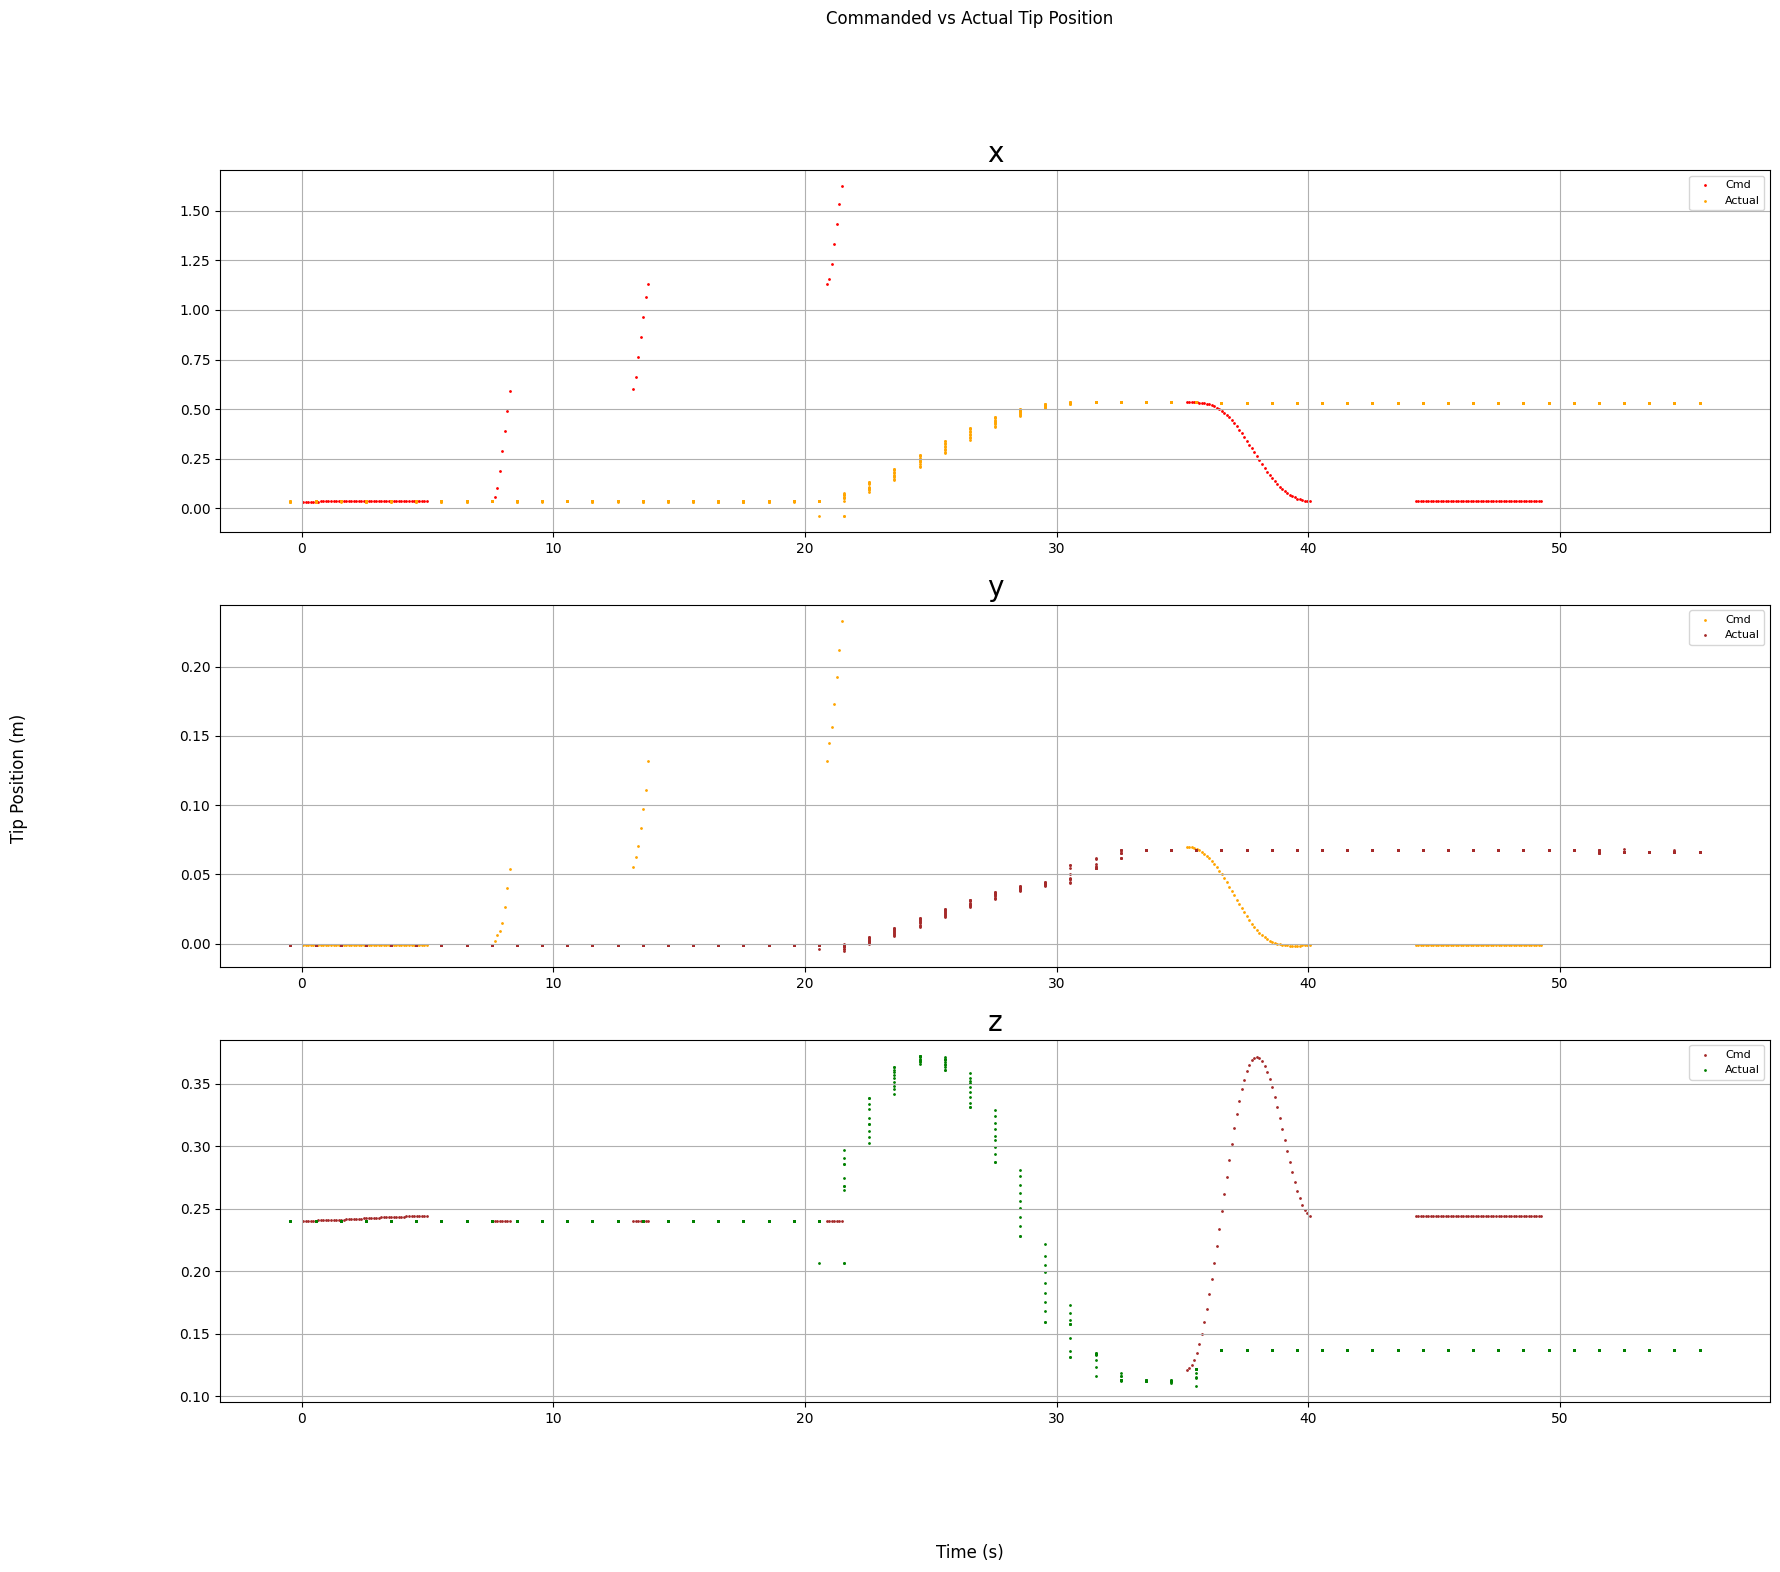

In [14]:
# fig, axes = plt.subplots(2, 4, constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 16))
                         
for i, column_name in enumerate(position_cmd.columns[1:]):
    print(column_name)
    # Plot x from command data
    axes[i].scatter(
        position_cmd['time'], 
        position_cmd[column_name], 
        label='Cmd', 
        color=COLORS[i],
        alpha=OPACITY_CMD,
        s=MARKER_SIZE
    )

    # Plot servo{i} from state data
    axes[i].scatter(
        position_state['time'], 
        position_state[column_name], 
        label='Actual', 
        color=COLORS[i + 1] if i < 3 else COLORS[0], 
        alpha=OPACITY_STATE,
        s=MARKER_SIZE
    )

    axes[i].set_title(column_name, size=20)
    axes[i].legend(fontsize=8, loc='best')
    axes[i].grid()

# Add labels and title
fig.supxlabel('Time (s)')
fig.supylabel('Tip Position (m)')
fig.suptitle('Commanded vs Actual Tip Position')

plt.show()